# Code generation with self-correction

AlphaCodium presented an approach for code generation that uses control flow.

Main idea: [construct an answer to a coding question iteratively.](https://x.com/karpathy/status/1748043513156272416?s=20). 

[AlphaCodium](https://github.com/Codium-ai/AlphaCodium) iteravely tests and improves an answer on public and AI-generated tests for a particular question. 

We will implement some of these ideas from scratch using [LangGraph](https://langchain-ai.github.io/langgraph/):

1. We show how to route user questions to different types of documentation
2. We we will show how to perform inline unit tests to confirm imports and code execution work
3. We will show how to use LangGraph to orchestrate this


In [18]:
from typing import TypedDict, Optional
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from typing import Literal


## Code Generation

Test with structured output.

In [19]:
# Select LLM
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Prompt
code_gen_prompt_claude = ChatPromptTemplate.from_messages(
    [(
        "system",
        """You are a coding assistant. Ensure any code you provide can be executed with all required imports and variables \n
        defined. Structure your answer: 1) a prefix describing the code solution, 2) the imports, 3) the functioning code block.
        \n Here is the user question:""",
    ),
    ("placeholder", "{messages}"),])


# Data model
class code(BaseModel):
    """Code output"""

    prefix: str = Field(description="Description of the problem and approach")
    imports: str = Field(description="Code block import statements")
    code: str = Field(description="Code block not including import statements")
    description: str = "Schema for code solutions to questions about LCEL."

# LLM
code_gen_chain = llm.with_structured_output(code, include_raw=False)

In [20]:
question = "Write a function for fibonacci."
messages = [("user", question)]

In [21]:
# Test
result = code_gen_chain.invoke(messages)
result

code(prefix='This function calculates the Fibonacci sequence up to the nth number using a simple iterative approach. It returns a list of Fibonacci numbers.', imports='', code='def fibonacci(n):\n    if n <= 0:\n        return []\n    elif n == 1:\n        return [0]\n    elif n == 2:\n        return [0, 1]\n    else:\n        fib_sequence = [0, 1]\n        for i in range(2, n):\n            next_fib = fib_sequence[-1] + fib_sequence[-2]\n            fib_sequence.append(next_fib)\n        return fib_sequence', description='Function to generate Fibonacci sequence up to the nth number.')

## State

In [8]:
from typing import Annotated, TypedDict

from langgraph.graph.message import AnyMessage, add_messages


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        error : Binary flag for control flow to indicate whether test error was tripped
        messages : With user question, error messages, reasoning
        generation : Code solution
        iterations : Number of tries
    """

    error: str
    messages: Annotated[list[AnyMessage], add_messages]
    generation: str
    iterations: int

## Graph

In [10]:
import uuid

### Parameters
max_iterations = 3


### Nodes
def generate(state: GraphState):
    """
    Generate a code solution

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation
    """

    print("---GENERATING CODE SOLUTION---")

    # State
    messages = state["messages"]
    iterations = state["iterations"]

    # Solution
    code_solution = code_gen_chain.invoke(messages)
    messages += [
        (
            "assistant",
            f"Here is my attempt to solve the problem: {code_solution.prefix} \n Imports: {code_solution.imports} \n Code: {code_solution.code}",
        )
    ]

    # Increment
    iterations = iterations + 1
    return {"generation": code_solution, "messages": messages, "iterations": iterations}


def code_check(state: GraphState):
    """
    Check code

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, error
    """

    print("---CHECKING CODE---")

    # State
    messages = state["messages"]
    code_solution = state["generation"]
    iterations = state["iterations"]

    # Get solution components
    imports = code_solution.imports
    code = code_solution.code

    # Check imports
    try:
        exec(imports)
    except Exception as e:
        print("---CODE IMPORT CHECK: FAILED---")
        error_message = [
            (
                "user",
                f"Your solution failed the import test. Here is the error: {e}. Reflect on this error and your prior attempt to solve the problem. (1) State what you think went wrong with the prior solution and (2) try to solve this problem again. Return the FULL SOLUTION. Use the code tool to structure the output with a prefix, imports, and code block:",
            )
        ]
        messages += error_message
        return {
            "generation": code_solution,
            "messages": messages,
            "iterations": iterations,
            "error": "yes",
        }

    # Check execution
    try:
        combined_code = f"{imports}\n{code}"
        print(f"CODE TO TEST: {combined_code}")
        # Use a shared scope for exec
        global_scope = {}
        exec(combined_code, global_scope)
    except Exception as e:
        print("---CODE BLOCK CHECK: FAILED---")
        error_message = [
            (
                "user",
                f"Your solution failed the code execution test: {e}) Reflect on this error and your prior attempt to solve the problem. (1) State what you think went wrong with the prior solution and (2) try to solve this problem again. Return the FULL SOLUTION. Use the code tool to structure the output with a prefix, imports, and code block:",
            )
        ]
        messages += error_message
        return {
            "generation": code_solution,
            "messages": messages,
            "iterations": iterations,
            "error": "yes",
        }

    # No errors
    print("---NO CODE TEST FAILURES---")
    return {
        "generation": code_solution,
        "messages": messages,
        "iterations": iterations,
        "error": "no",
    }


### Conditional edges


def decide_to_finish(state: GraphState):
    """
    Determines whether to finish.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """
    error = state["error"]
    iterations = state["iterations"]

    if error == "no" or iterations == max_iterations:
        print("---DECISION: FINISH---")
        return "end"
    else:
        print("---DECISION: RE-TRY SOLUTION---")
        return "generate"


### Utilities


def _print_event(event: dict, _printed: set, max_length=1500):
    current_state = event.get("dialog_state")
    if current_state:
        print("Currently in: ", current_state[-1])
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=True)
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            print(msg_repr)
            _printed.add(message.id)

In [11]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, StateGraph, START

builder = StateGraph(GraphState)

# Define the nodes
builder.add_node("generate", generate)  # generation solution
builder.add_node("check_code", code_check)  # check code

# Build graph
builder.add_edge(START, "generate")
builder.add_edge("generate", "check_code")
builder.add_conditional_edges(
    "check_code",
    decide_to_finish,
    {
        "end": END,
        "generate": "generate",
    },
)

memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

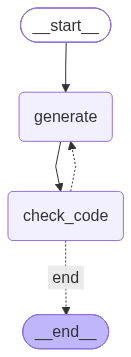

In [12]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [13]:
_printed = set()
thread_id = str(uuid.uuid4())
config = {
    "configurable": {
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}

question = "Write a Python program that prints 'Hello, World!' to the console."
events = graph.stream(
    {"messages": [("user", question)], "iterations": 0}, config, stream_mode="values"
)
for event in events:
    _print_event(event, _printed)

================================ Human Message =================================

Write a Python program that prints 'Hello, World!' to the console.
---GENERATING CODE SOLUTION---
================================== Ai Message ==================================

Here is my attempt to solve the problem: This program prints a simple greeting message to the console. 
 Imports:  
 Code: print('Hello, World!')
---CHECKING CODE---
CODE TO TEST: 
print('Hello, World!')
Hello, World!
---NO CODE TEST FAILURES---
---DECISION: FINISH---


In [14]:
_printed = set()
thread_id = str(uuid.uuid4())
config = {
    "configurable": {
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}

question = """Create a Python program that checks if a given string is a palindrome. A palindrome is a word, phrase, number, or other sequence of characters that reads the same forward and backward (ignoring spaces, punctuation, and capitalization).

Requirements:
The program should define a function is_palindrome(s) that takes a string s as input.
The function should return True if the string is a palindrome and False otherwise.
Ignore spaces, punctuation, and case differences when checking for palindromes.

Give an example of it working on an example input word."""

events = graph.stream(
    {"messages": [("user", question)], "iterations": 0}, config, stream_mode="values"
)
for event in events:
    _print_event(event, _printed)

================================ Human Message =================================

Create a Python program that checks if a given string is a palindrome. A palindrome is a word, phrase, number, or other sequence of characters that reads the same forward and backward (ignoring spaces, punctuation, and capitalization).

Requirements:
The program should define a function is_palindrome(s) that takes a string s as input.
The function should return True if the string is a palindrome and False otherwise.
Ignore spaces, punctuation, and case differences when checking for palindromes.

Give an example of it working on an example input word.
---GENERATING CODE SOLUTION---
================================== Ai Message ==================================

Here is my attempt to solve the problem: The program defines a function `is_palindrome(s)` that checks if the input string is a palindrome by normalizing it (removing spaces, punctuation, and converting to lowercase) and comparing it to its reverse

In [15]:
_printed = set()
thread_id = str(uuid.uuid4())
config = {
    "configurable": {
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}

question = """Write a program that prints the numbers from 1 to 100. 
But for multiples of three, print "Fizz" instead of the number, and for the multiples of five, print "Buzz". 
For numbers which are multiples of both three and five, print "FizzBuzz"."""

events = graph.stream(
    {"messages": [("user", question)], "iterations": 0}, config, stream_mode="values"
)
for event in events:
    _print_event(event, _printed)

================================ Human Message =================================

Write a program that prints the numbers from 1 to 100. 
But for multiples of three, print "Fizz" instead of the number, and for the multiples of five, print "Buzz". 
For numbers which are multiples of both three and five, print "FizzBuzz".
---GENERATING CODE SOLUTION---
================================== Ai Message ==================================

Here is my attempt to solve the problem: This program implements the FizzBuzz challenge, which involves printing numbers from 1 to 100 with specific substitutions for multiples of 3 and 5. The approach uses a loop to iterate through the numbers and conditional statements to determine what to print. 
 Imports:  
 Code: for i in range(1, 101):
    if i % 3 == 0 and i % 5 == 0:
        print("FizzBuzz")
    elif i % 3 == 0:
        print("Fizz")
    elif i % 5 == 0:
        print("Buzz")
    else:
        print(i)
---CHECKING CODE---
CODE TO TEST: 
for i in rang

In [16]:
import uuid

_printed = set()
thread_id = str(uuid.uuid4())
config = {
    "configurable": {
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}

question = """I want to vectorize a function

        frame = np.zeros((out_h, out_w, 3), dtype=np.uint8)
        for i, val1 in enumerate(rows):
            for j, val2 in enumerate(cols):
                for j, val3 in enumerate(ch):
                    # Assuming you want to store the pair as tuples in the matrix
                    frame[i, j, k] = image[val1, val2, val3]

        out.write(np.array(frame))

with a simple numpy function that does something like this what is it called. Show me a test case with this working."""

events = graph.stream(
    {"messages": [("user", question)], "iterations": 0}, config, stream_mode="values"
)
for event in events:
    _print_event(event, _printed)

================================ Human Message =================================

I want to vectorize a function

        frame = np.zeros((out_h, out_w, 3), dtype=np.uint8)
        for i, val1 in enumerate(rows):
            for j, val2 in enumerate(cols):
                for j, val3 in enumerate(ch):
                    # Assuming you want to store the pair as tuples in the matrix
                    frame[i, j, k] = image[val1, val2, val3]

        out.write(np.array(frame))

with a simple numpy function that does something like this what is it called. Show me a test case with this working.
---GENERATING CODE SOLUTION---
================================== Ai Message ==================================

Here is my attempt to solve the problem: The goal is to vectorize the nested loops that populate the `frame` array using NumPy's advanced indexing capabilities. This can be achieved by creating an index array for each dimension and using them to directly index into the `image` array, w

In [17]:
_printed = set()
thread_id = str(uuid.uuid4())
config = {
    "configurable": {
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}

question = """Create a Python program that allows two players to play a game of Tic-Tac-Toe. The game should be played on a 3x3 grid. The program should:

- Allow players to take turns to input their moves.
- Check for invalid moves (e.g., placing a marker on an already occupied space).
- Determine and announce the winner or if the game ends in a draw.

Requirements:
- Use a 2D list to represent the Tic-Tac-Toe board.
- Use functions to modularize the code.
- Validate player input.
- Check for win conditions and draw conditions after each move."""

events = graph.stream(
    {"messages": [("user", question)], "iterations": 0}, config, stream_mode="values"
)
for event in events:
    _print_event(event, _printed)

================================ Human Message =================================

Create a Python program that allows two players to play a game of Tic-Tac-Toe. The game should be played on a 3x3 grid. The program should:

- Allow players to take turns to input their moves.
- Check for invalid moves (e.g., placing a marker on an already occupied space).
- Determine and announce the winner or if the game ends in a draw.

Requirements:
- Use a 2D list to represent the Tic-Tac-Toe board.
- Use functions to modularize the code.
- Validate player input.
- Check for win conditions and draw conditions after each move.
---GENERATING CODE SOLUTION---
================================== Ai Message ==================================

Here is my attempt to solve the problem: This program implements a simple Tic-Tac-Toe game for two players. It uses a 2D list to represent the game board and includes functions to handle player moves, check for win conditions, and validate input. The game alternates t